In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Veri içeri aktarıldı.
data_aylik = pd.read_excel("Elektrik_uretim_tuketim_aylik.xlsx")
data_gunluk = pd.read_excel("Elektrik_uretim_tuketim_gunluk.xlsx")
data_saatlik = pd.read_excel("Elektrik_uretim_tuketim_saatlik.xlsx")

In [3]:
# Veri DateTime sütunu index yapıldı ve zaman dilimi olarak belirtildi.
data_saatlik = data_saatlik.set_index("DateTime")
data_saatlik.index = pd.to_datetime(data_saatlik.index)

data_gunluk = data_gunluk.set_index("DateTime")
data_gunluk.index = pd.to_datetime(data_gunluk.index)

data_aylik = data_aylik.set_index("DateTime")
data_aylik.index = pd.to_datetime(data_aylik.index)

In [4]:
data_saatlik.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [5]:
data_gunluk.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01,142984,142186,33402,8246,30861,34032,33809,1039,787
2019-01-02,151729,163097,33380,26562,30065,38764,32175,1280,858
2019-01-03,174098,172854,32929,23743,35453,43732,35225,800,956
2019-01-04,183242,191724,32914,44510,33884,41808,36469,1092,1038
2019-01-05,177114,164069,33440,15108,29089,44158,39031,2226,1008


In [6]:
data_aylik.head()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
DateTime,,,,,,,,,
2019-01-01,5767613,5481374,1028086,794158,985004,1300555,1297308,35169,40476
2019-02-01,5110608,5124081,928065,643425,1142669,1116244,1170975,82694,39306
2019-03-01,5195645,5236790,1026183,658460,1334099,818902,1217554,141971,39169
2019-04-01,4789794,4829352,992048,622945,1409683,442912,1192839,134735,33330
2019-05-01,4746186,4988630,540551,542424,2310922,350846,1073410,144170,25414


In [7]:
data_aylik.describe()

,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
count,7.500000e+01,7.500000e+01,7.500000e+01,7.500000e+01,7.500000e+01,7.500000e+01,7.500000e+01,75.000000,75.000000
mean,4.713847e+06,4.608191e+06,9.262928e+05,5.573932e+05,1.294764e+06,8.427723e+05,8.223014e+05,124091.466667,39680.506667
std,4.941803e+05,5.543176e+05,1.467856e+05,1.712602e+05,3.995433e+05,2.721173e+05,2.158693e+05,56822.698861,8863.032330
min,2.750062e+06,2.589810e+06,4.989240e+05,2.841380e+05,5.663970e+05,2.679350e+05,3.653710e+05,27360.000000,23326.000000
25%,4.417976e+06,4.278334e+06,9.104930e+05,4.174085e+05,9.934365e+05,6.693210e+05,6.435900e+05,78227.000000,33513.000000
50%,4.676981e+06,4.594798e+06,9.920480e+05,5.365290e+05,1.266425e+06,8.328290e+05,8.406420e+05,129863.000000,40476.000000
75%,5.013066e+06,4.980392e+06,1.017762e+06,6.739330e+05,1.487990e+06,1.083630e+06,9.554950e+05,163475.500000,46784.000000
max,5.767613e+06,5.516962e+06,1.054861e+06,1.022197e+06,2.379763e+06,1.354553e+06,1.297308e+06,280782.000000,55422.000000


In [8]:
# Veri setinin boyutu incelendi.
data_aylik.shape

(75, 9)

In [9]:
print(f'Toplam satır (Gözlem) sayısı : {data_saatlik.shape[0]}')

Toplam satır (Gözlem) sayısı : 54170


In [10]:
# Veride kaç tane sütun (Değişken) olduğu gözlemlendi.
print(f'Toplam sütun (Değişken) sayısı : {data_saatlik.shape[1]}')

Toplam sütun (Değişken) sayısı : 9


In [11]:
print(f'Toplam satır (Gözlem) sayısı : {data_gunluk.shape[0]}')

Toplam satır (Gözlem) sayısı : 2270


In [12]:
print(f'Toplam sütun (Değişken) sayısı : {data_gunluk.shape[1]}')

Toplam sütun (Değişken) sayısı : 9


In [13]:
# Veride kaç tane satır (Gözlem) olduğu incelendi.
print(f'Toplam satır (Gözlem) sayısı : {data_aylik.shape[0]}')

Toplam satır (Gözlem) sayısı : 75


In [14]:
print(f'Toplam sütun (Değişken) sayısı : {data_aylik.shape[1]}')

Toplam sütun (Değişken) sayısı : 9


In [19]:
# Veride boş değerler incelendi.
print(f'Boş Değerlerin Sayısı : \n{data_saatlik.isnull().sum()}')

Boş Değerlerin Sayısı : 
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


In [16]:
print(f'Boş Değerlerin Sayısı : \n{data_gunluk.isnull().sum()}')

Boş Değerlerin Sayısı : 
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


In [17]:
print(f'Boş Değerlerin Sayısı : \n{data_aylik.isnull().sum()}')

Boş Değerlerin Sayısı : 
Consumption      0
Production       0
Nuclear          0
Wind             0
Hydroelectric    0
Oil and Gas      0
Coal             0
Solar            0
Biomass          0
dtype: int64


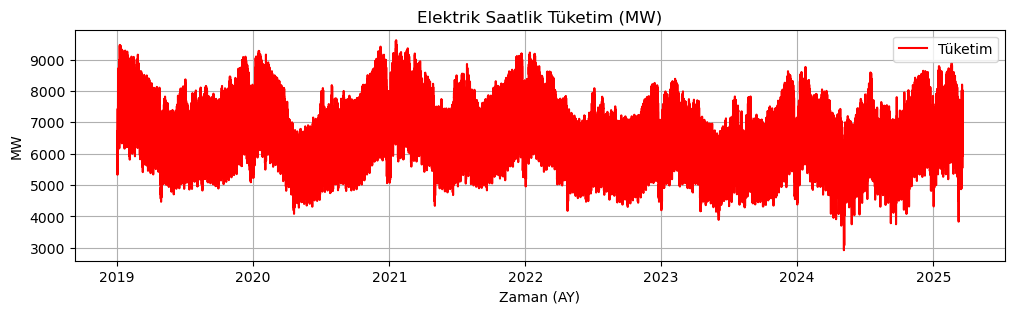

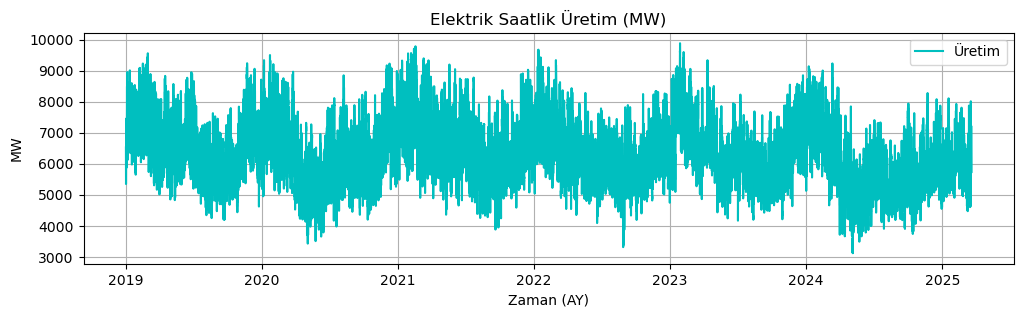

In [18]:
uretim_tipi = ["Consumption","Production"]
label_uretim = ["Tüketim","Üretim"]
renkler = {"Consumption":"r", "Production":"c"}

for uretim, label in zip(uretim_tipi, label_uretim):
    plt.figure(figsize=(12, 3))
    plt.plot(data_saatlik.index, data_saatlik[uretim], linestyle="-", color=renkler.get(uretim, "k"), label=label)
    plt.title(f"Elektrik Saatlik {label} (MW)")
    plt.ylabel("MW")
    plt.xlabel("Zaman (AY)")
    plt.grid(True)
    plt.legend()
    plt.show()

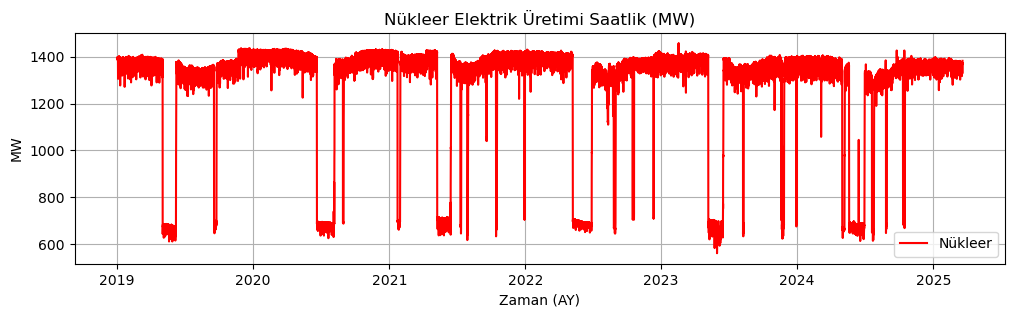

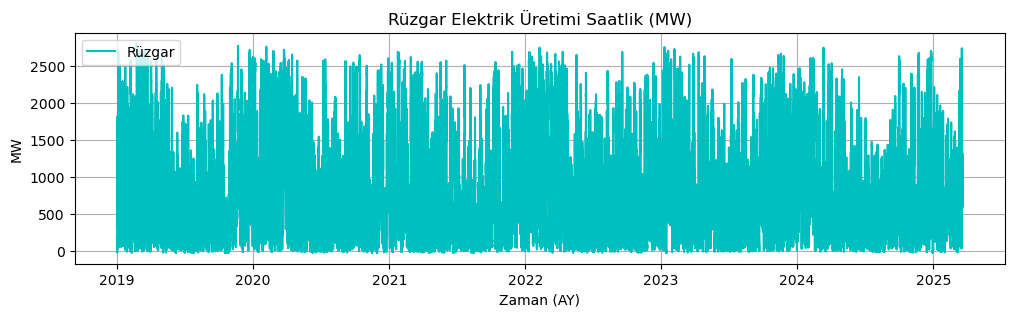

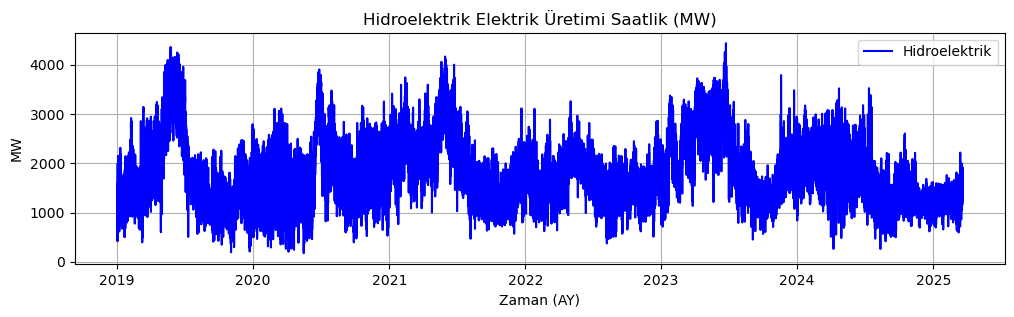

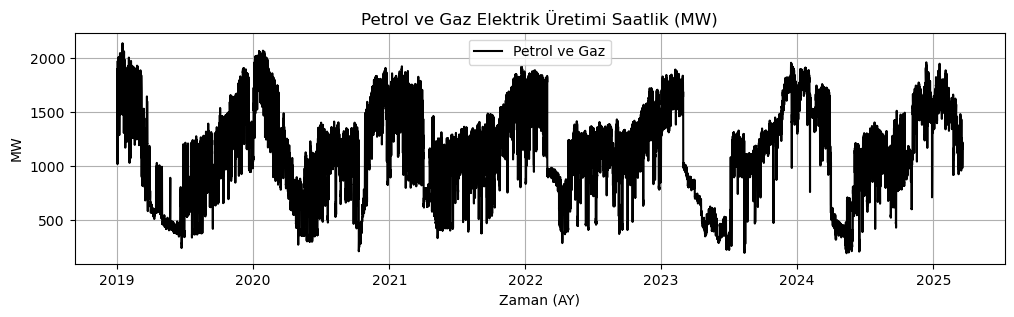

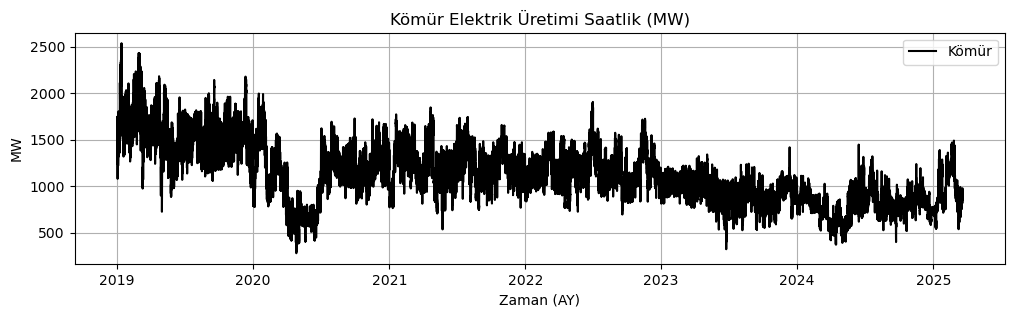

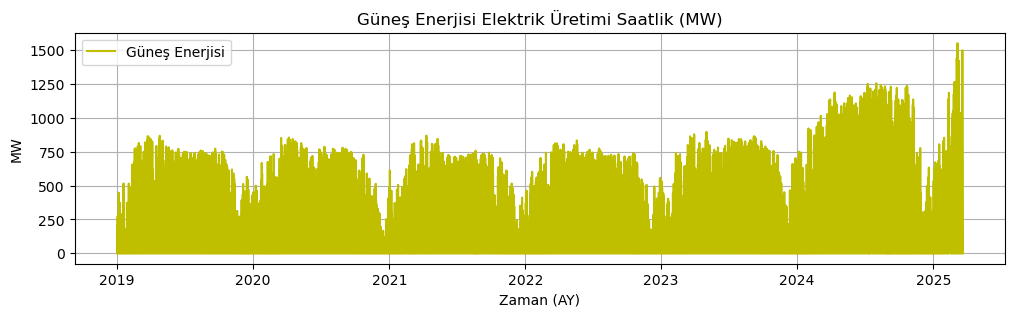

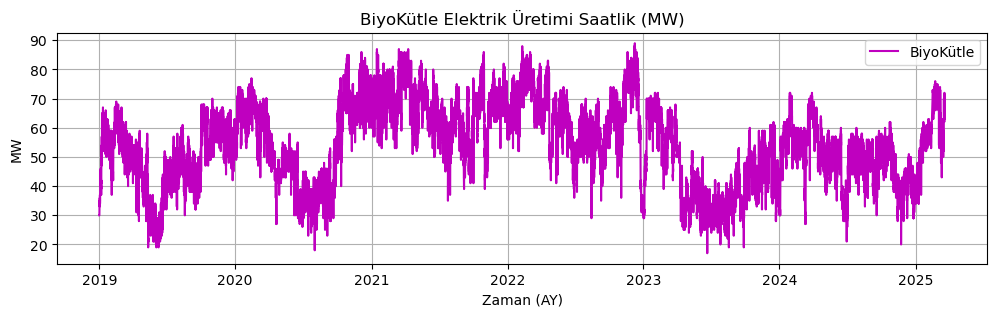

In [19]:
uretim_tipi = ['Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
label_uretim = ["Nükleer", "Rüzgar", "Hidroelektrik", "Petrol ve Gaz", "Kömür", "Güneş Enerjisi", "BiyoKütle"]
renkler = {"Nuclear":"r", "Wind":"c", "Hydroelectric":"b", "Oil and Gas":"k", "Coal":"k", "Solar":"y", "Biomass":"m"}

for uretim, label in zip(uretim_tipi, label_uretim):
    plt.figure(figsize=(12, 3))
    plt.plot(data_saatlik.index, data_saatlik[uretim], linestyle="-", color=renkler.get(uretim, "k"), label=label)
    plt.title(f"{label} Elektrik Üretimi Saatlik (MW)")
    plt.ylabel("MW")
    plt.xlabel("Zaman (AY)")
    plt.grid(True)
    plt.legend()
    plt.show()

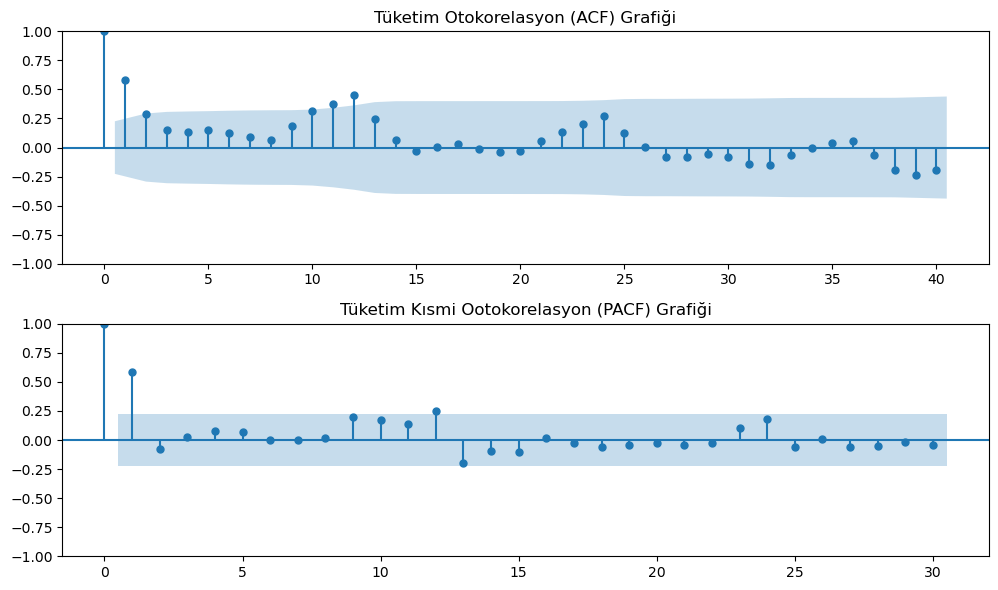

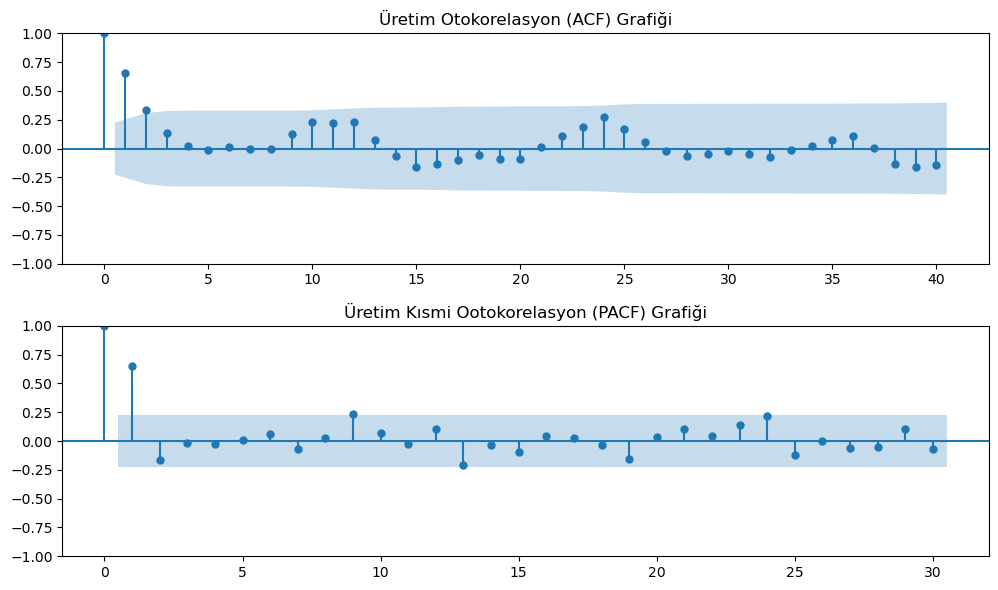

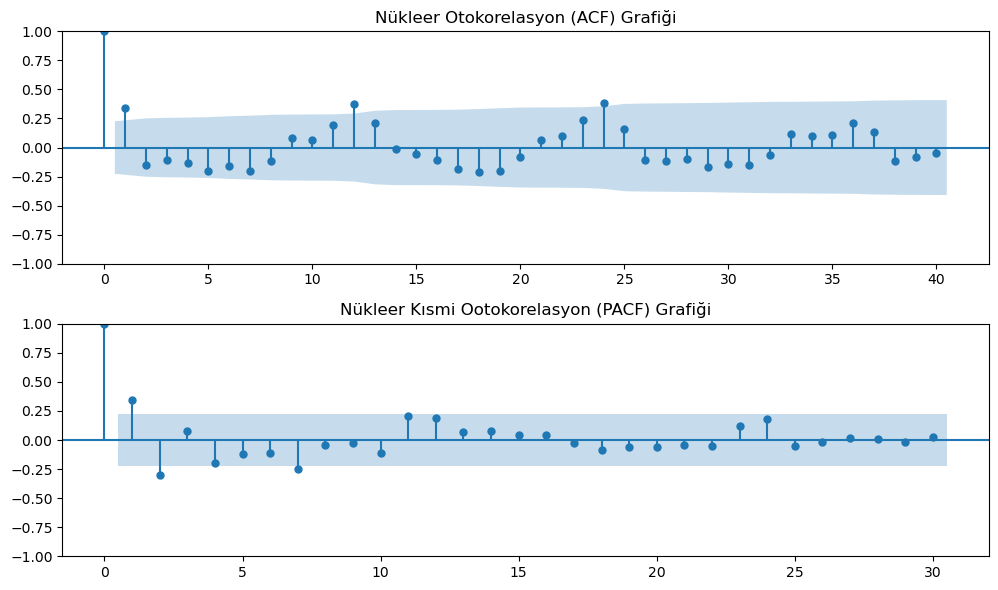

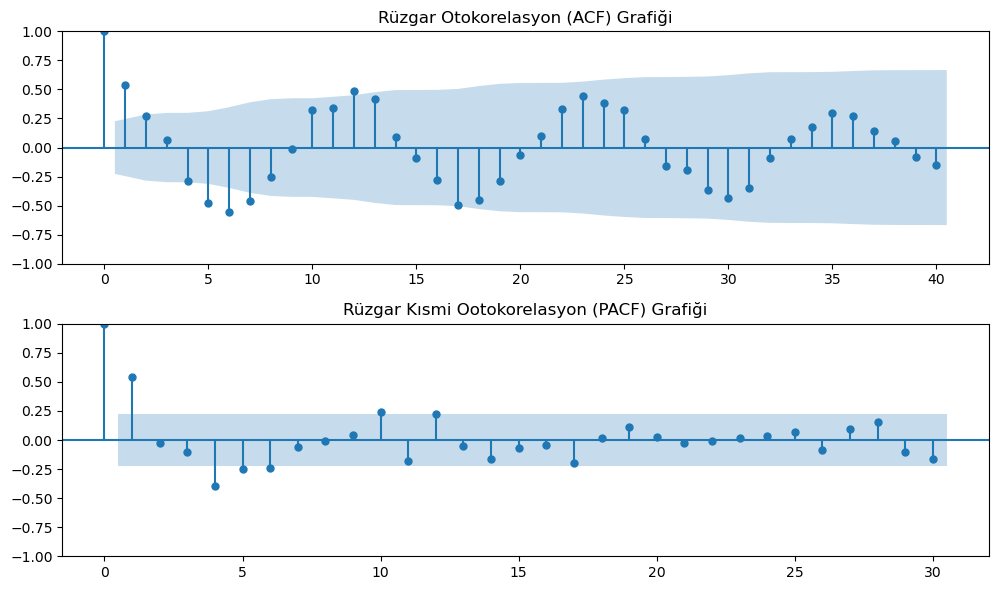

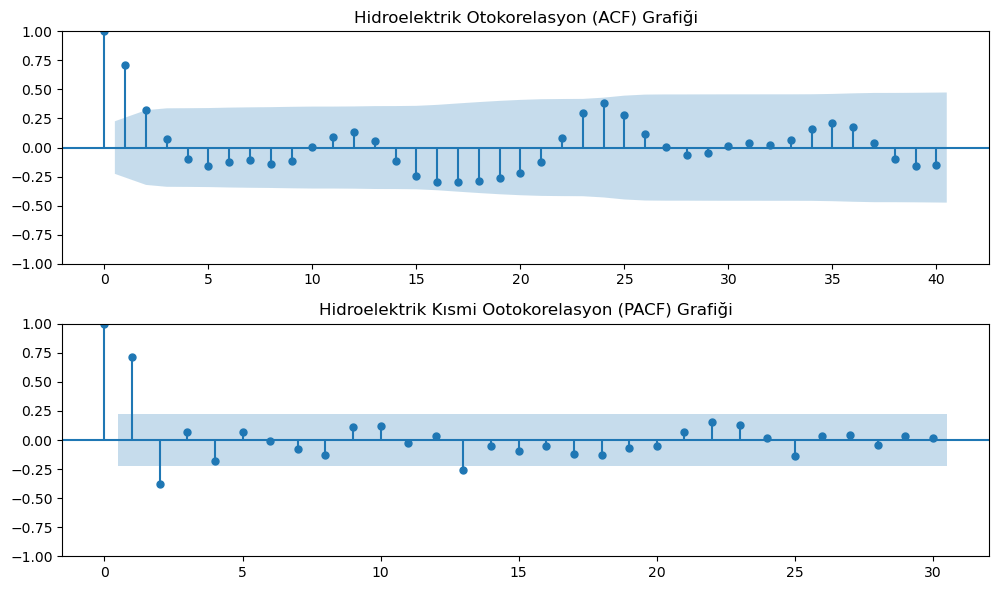

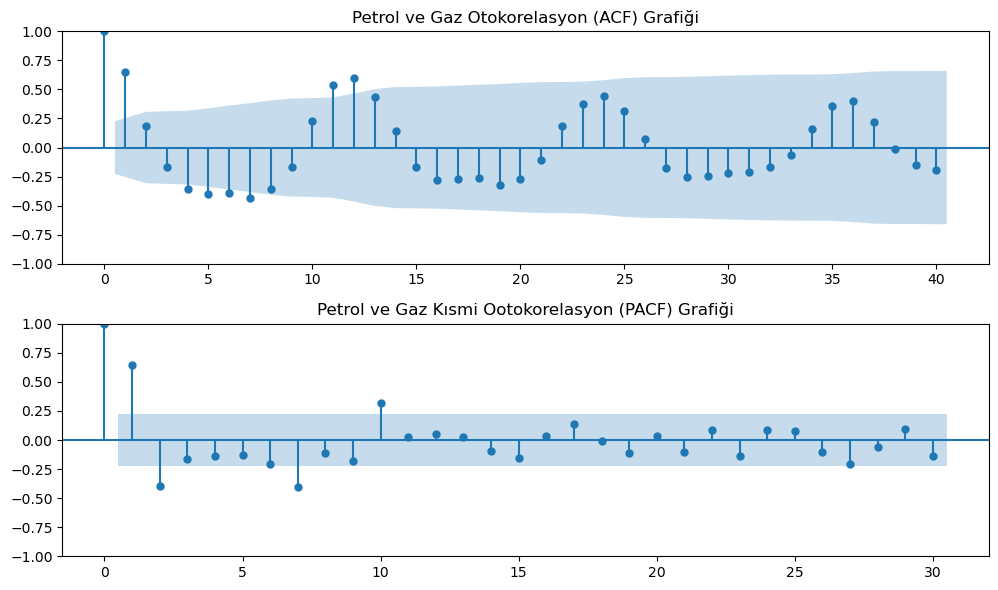

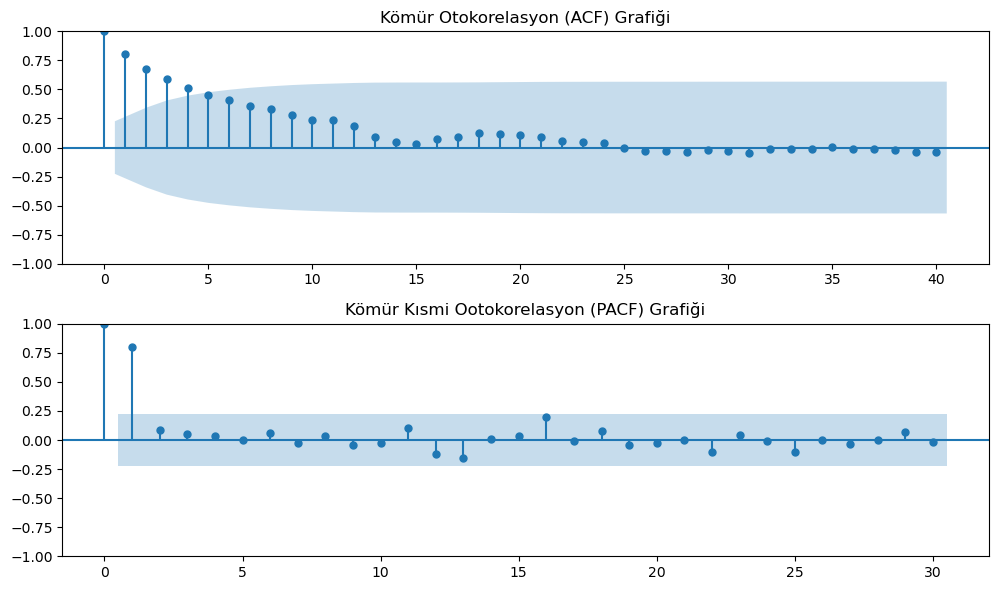

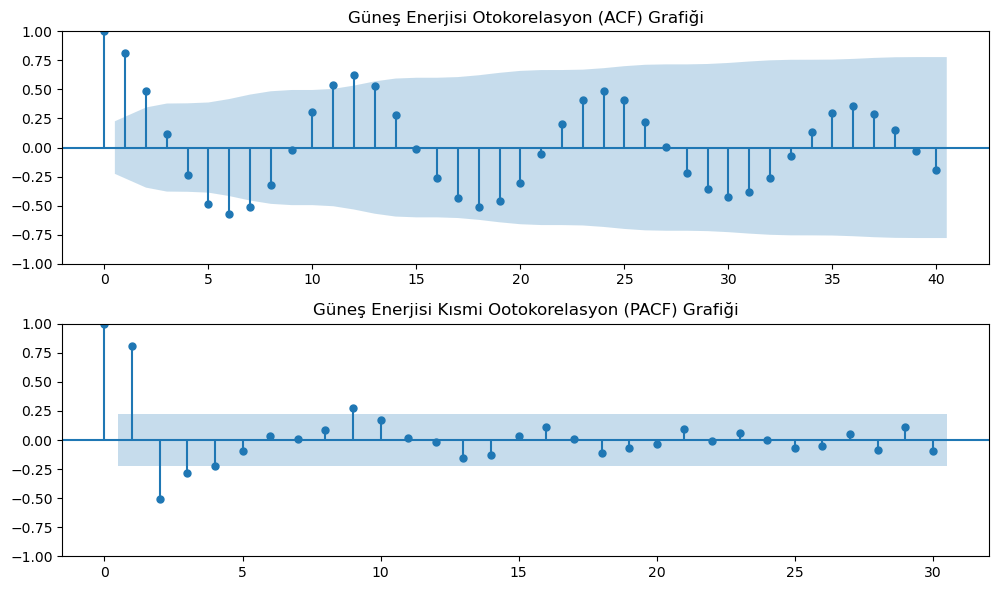

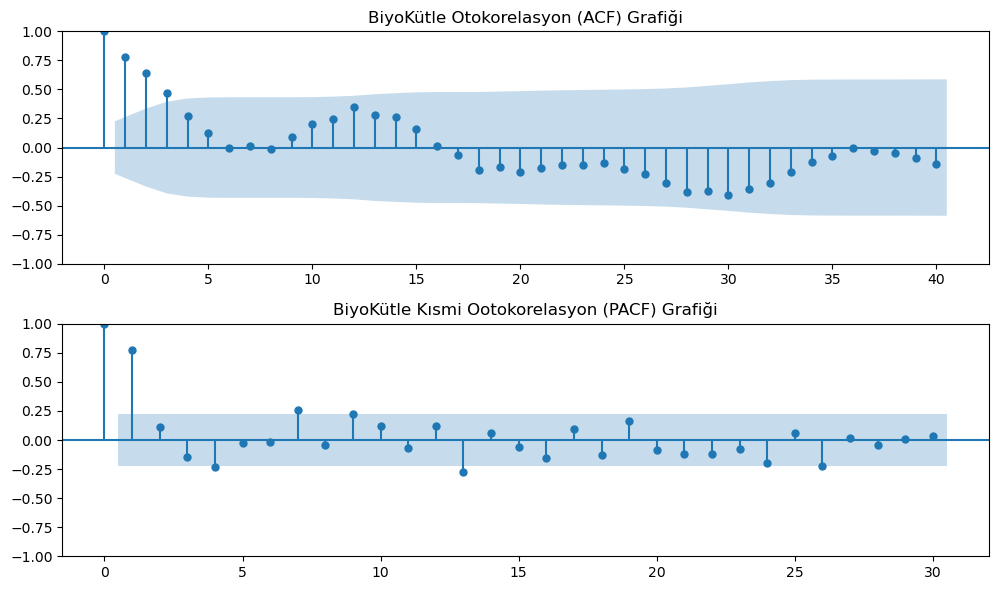

In [21]:
özellik_tipi = ['Consumption','Production','Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
label_tipi = ["Tüketim","Üretim","Nükleer", "Rüzgar", "Hidroelektrik", "Petrol ve Gaz", "Kömür", "Güneş Enerjisi", "BiyoKütle"]



for özellik,label in zip(özellik_tipi, label_tipi):
    fig, ax = plt.subplots(2,1, figsize=(10,6))
    plot_acf(data_aylik[özellik], lags=40, ax=ax[0])
    ax[0].set_title(f"{label} Otokorelasyon (ACF) Grafiği")
    plot_pacf(data_aylik[özellik], lags=30, ax=ax[1], method='ywm')
    ax[1].set_title(f"{label} Kısmi Ootokorelasyon (PACF) Grafiği")
    plt.tight_layout()
    plt.show()

# ARIMA MODELİ (Aylık veri kullanıldı)

In [21]:
p = range(0, 4)
d = range(0, 4)
q = range(0, 4)
pdq = list(itertools.product(p, d, q))

In [23]:
y = data_aylik["Consumption"]
results = []

for order in pdq:
    try:
        model = ARIMA(y, order=order)
        model_fit = model.fit()
        
        results.append({
            "p": order[0],
            "d": order[1],
            "q": order[2],
            "AIC": model_fit.aic,
            "BIC": model_fit.bic
        })
        
    except:
        continue

In [24]:
results_data = pd.DataFrame(results)
results_data

,p,d,q,AIC,BIC
0,0,0,0,2432.244022,2436.878998
1,0,0,1,2150.567416,2157.519880
2,0,0,2,2140.063190,2149.333142
3,0,0,3,2139.869726,2151.457167
4,0,1,0,2109.766404,2112.070469
...,...,...,...,...,...
59,3,2,3,2094.135949,2110.169165
60,3,3,0,2119.908639,2129.015304
61,3,3,1,2090.914914,2102.298245
62,3,3,2,2086.904710,2100.564707


In [25]:
best_bic = results_data.loc[results_data["BIC"].idxmin()]
best_bic

p         1.000000
d         3.000000
q         2.000000
AIC    2082.581029
BIC    2091.687693
Name: 30, dtype: float64

In [26]:
# En iyi değerlerle ARIMA modeli kuruldu
best_order = (int(best_bic.p), int(best_bic.d), int(best_bic.q))

final_model = ARIMA(y, order=best_order)
final_model_fit = final_model.fit()

print(final_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            Consumption   No. Observations:                   75
Model:                 ARIMA(1, 3, 2)   Log Likelihood               -1037.291
Date:                Fri, 19 Dec 2025   AIC                           2082.581
Time:                        14:27:43   BIC                           2091.688
Sample:                    01-01-2019   HQIC                          2086.206
                         - 03-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3736      0.174      2.142      0.032       0.032       0.715
ma.L1         -1.9327      0.152    -12.744      0.000      -2.230      -1.635
ma.L2          0.9468      0.150      6.301      0.0

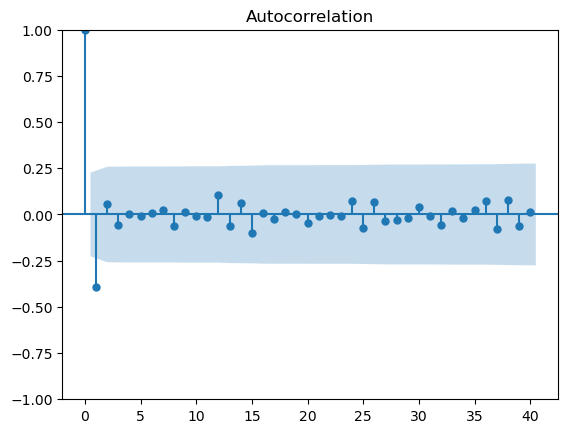

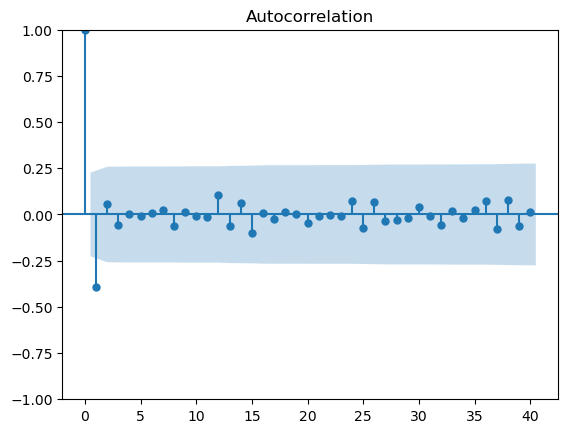

In [27]:
# Artık Analizi
resid = final_model_fit.resid
plot_acf(resid, lags=40)

In [28]:
# Ljung–Box (hataların bağımsızlık) testi yapıldı 
# p-value > 0.05 → model uygun
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
lb = lb.reset_index()
lb = lb.rename(columns={
    "index": "Gecikme (Lag)",
    "lb_stat": "Ljung–Box Q İstatistiği",
    "lb_pvalue": "p-değeri"
})

lb

,Gecikme (Lag),Ljung–Box Q İstatistiği,p-değeri
0,10,12.777332,0.236389
1,20,15.869388,0.724693


In [29]:
# Tahmin edilen ARIMA modeline ait artıklar üzerinde Ljung–Box testi uygulanmıştır. Test sonuçlarına göre 10 ve 20 gecikme seviyelerinde elde edilen p-değerleri sırasıyla 0.1097 ve 0.5257 olup %5 anlamlılık düzeyinde istatistiksel olarak anlamlı bulunmamıştır. Bu bulgular, model artıklarının otokorelasyon içermediğini ve beyaz gürültü süreci sergilediğini göstermektedir. Dolayısıyla kurulan ARIMA modelinin yeterli olduğu sonucuna ulaşılmıştır.

In [30]:
# Ljung–Box testi sonuçları, ARIMA modeline ait artıkların hem kısa vadeli (10 gecikme) hem de orta vadeli (20 gecikme) otokorelasyon içermediğini göstermektedir. Elde edilen p-değerlerinin %5 anlamlılık düzeyinin üzerinde olması, model artıklarının beyaz gürültü süreci sergilediğini ve modelin zaman serisinin dinamik yapısını yeterli düzeyde yakaladığını ortaya koymaktadır.

In [22]:
# Tüm değişkenler için ARIMA
def arima_grid_search(y, pdq):
    results = []
    
    for order in pdq:
        try:
            model = ARIMA(y, order=order)
            model_fit = model.fit()
            
            results.append({
                "p": order[0],
                "d": order[1],
                "q": order[2],
                "AIC": model_fit.aic,
                "BIC": model_fit.bic
            })
        except:
            continue
            
    return pd.DataFrame(results)

In [23]:
özellik_tipi = ['Consumption','Production','Nuclear', 'Wind', 'Hydroelectric', 'Oil and Gas', 'Coal', 'Solar', 'Biomass']
label_tipi = ["Tüketim","Üretim","Nükleer", "Rüzgar", "Hidroelektrik", "Petrol ve Gaz", "Kömür", "Güneş Enerjisi", "BiyoKütle"]

In [24]:
all_results = {}

for col in özellik_tipi:
    y = data_aylik[col].dropna()
    all_results[col] = arima_grid_search(y, pdq)

In [25]:
best_models = []

for col, df_res in all_results.items():
    best = df_res.loc[df_res["BIC"].idxmin()]
    best_models.append({
        "Değişken": col,
        "p": int(best.p),
        "d": int(best.d),
        "q": int(best.q),
        "AIC": best.AIC,
        "BIC": best.BIC
    })

best_models_df = pd.DataFrame(best_models)
best_models_df

,Değişken,p,d,q,AIC,BIC
0,Consumption,1,3,2,2082.581029,2091.687693
1,Production,1,3,2,2088.694000,2097.800665
2,Nuclear,2,3,2,1958.757364,1970.140694
3,Wind,2,3,3,1958.215982,1971.875978
4,Hydroelectric,0,3,3,2033.512399,2042.619063
5,Oil and Gas,0,3,2,2000.213815,2007.043813
6,Coal,0,3,2,1916.198683,1923.028681
7,Solar,2,2,3,1698.790455,1712.533212
8,Biomass,0,3,2,1474.905056,1481.735054


In [35]:
# ek metrikler eklendi sadece

In [36]:
def forecast_metrics(y_train, y_test, forecast):
    mae = mean_absolute_error(y_test, forecast)
    rmse = np.sqrt(mean_squared_error(y_test, forecast))
    mape = np.mean(np.abs((y_test - forecast) / y_test)) * 100
    
    # MASE için naive tahmin (bir önceki gözlem)
    naive_forecast = y_train[1:]
    naive_actual = y_train[:-1]
    mae_naive = mean_absolute_error(naive_actual, naive_forecast)
    
    mase = mae / mae_naive
    
    return mae, rmse, mape, mase

In [37]:
best_models = []

test_size = 12  # örn: son 12 gözlem test (aylık veri için uygun)

for col, df_res in all_results.items():
    
    # En iyi model (BIC)
    best = df_res.loc[df_res["BIC"].idxmin()]
    p, d, q = int(best.p), int(best.d), int(best.q)
    
    y = data_aylik[col].dropna()
    
    # Train-test split
    y_train = y[:-test_size]
    y_test = y[-test_size:]
    
    # Modeli train üzerinde kur
    model = ARIMA(y_train, order=(p, d, q))
    model_fit = model.fit()
    
    # Tahmin
    forecast = model_fit.forecast(steps=test_size)
    
    # Metrikler
    mae, rmse, mape, mase = forecast_metrics(
        y_train.values,
        y_test.values,
        forecast.values
    )
    
    best_models.append({
        "Değişken": col,
        "p": p,
        "d": d,
        "q": q,
        "AIC": best.AIC,
        "BIC": best.BIC,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "MASE": mase
    })

best_models_df = pd.DataFrame(best_models)
best_models_df

,Değişken,p,d,q,AIC,BIC,MAE,RMSE,MAPE (%),MASE
0,Consumption,1,3,2,2082.581029,2091.687693,621544.118422,792409.841027,14.034128,2.324568
1,Production,1,3,2,2088.694000,2097.800665,763978.560195,922121.146052,20.037035,2.663064
2,Nuclear,2,3,2,1958.757364,1970.140694,201853.793554,258837.093504,30.177985,1.818428
3,Wind,2,3,3,1958.215982,1971.875978,299133.773742,321263.424184,75.602153,2.350711
4,Hydroelectric,0,3,3,2033.512399,2042.619063,829539.080314,938238.320383,105.025341,3.716397
5,Oil and Gas,0,3,2,2000.213815,2007.043813,576910.610643,620565.202522,100.338724,3.787703
6,Coal,0,3,2,1916.198683,1923.028681,339389.438318,378405.064438,60.253540,4.088535
7,Solar,2,2,3,1698.790455,1712.533212,70266.591299,78501.050887,63.075174,2.770076
8,Biomass,0,3,2,1474.905056,1481.735054,10173.297061,11374.366489,32.307336,2.357500
